In [1]:
import pandas as pd
import pickle

# Import the dataframe
df_ml_LS = pd.read_csv('/content/df_ml_LS.csv')

# Import the model
with open('/content/xgboost_LS_model.pkl', 'rb') as f:
    model = pickle.load(f)


=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     44122
           1       0.58      0.91      0.71      1554

    accuracy                           0.97     45676
   macro avg       0.79      0.95      0.85     45676
weighted avg       0.98      0.97      0.98     45676


=== MATRIZ DE CONFUSÃO (VALORES ABSOLUTOS) ===
        Pred 0  Pred 1
Real 0   43112    1010
Real 1     134    1420

ROC-AUC Score: 0.9892

=== FEATURE IMPORTANCE COMPLETA ===
N_telephony_provider_unavailable_anteriores          0.217934
N_agent_hangup_anteriores                            0.143029
n_inactivity_anteriores                              0.127171
ddd                                                  0.121976
N_user_hangup_anteriores                             0.117630
N_dial_busy_anteriores                               0.097694
ultima_disconnection_reason                          0.045944
Regiao                     

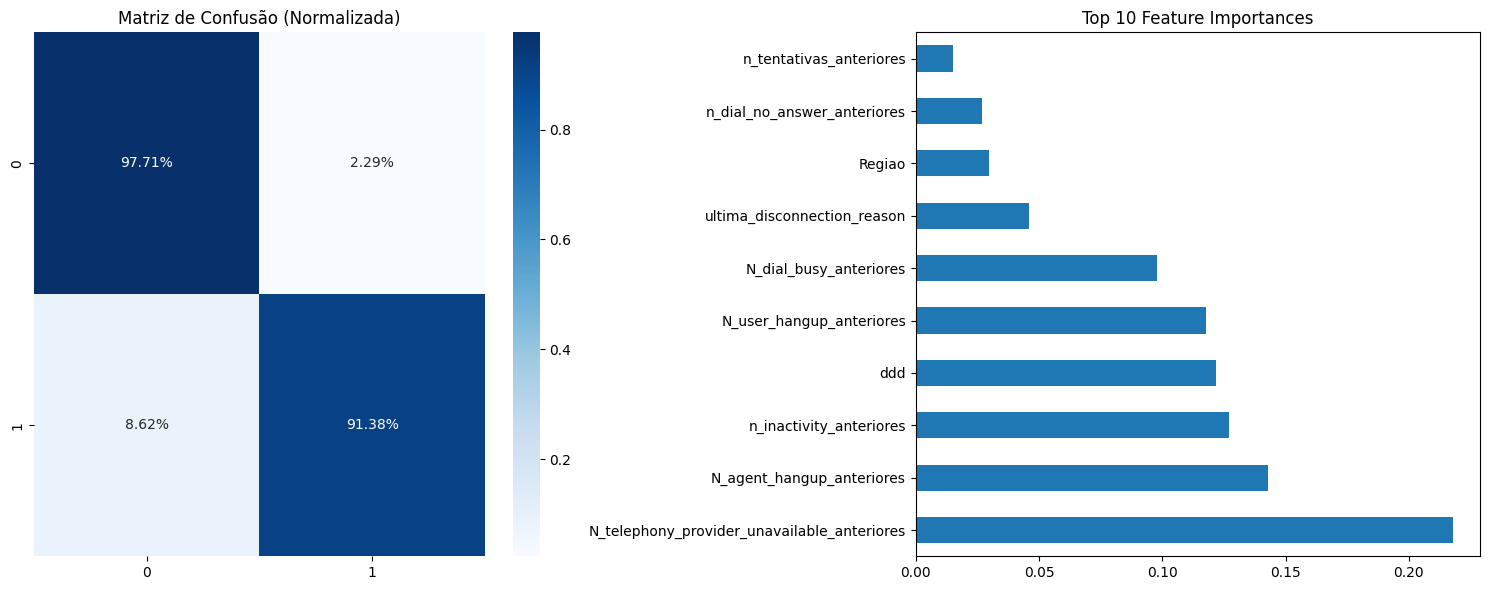

In [2]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Preparação dos dados
X = df_ml_LS.drop('target', axis=1)
y = df_ml_LS['target']

# Converter ddd e objetos para category para compatibilidade com o modelo XGBoost
X['ddd'] = X['ddd'].astype(str).astype('category')
for col in X.select_dtypes(['object']).columns:
    X[col] = X[col].astype('category')

# Gerar as predições
try:
    y_pred = model.predict(X)
    y_probs = model.predict_proba(X)[:, 1]

    # --- MÉTRICAS EM TEXTO (COMPLETAS) ---
    print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
    print(classification_report(y, y_pred))

    print("\n=== MATRIZ DE CONFUSÃO (VALORES ABSOLUTOS) ===")
    cm = confusion_matrix(y, y_pred)
    print(pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))

    roc_auc = roc_auc_score(y, y_probs)
    print(f"\nROC-AUC Score: {roc_auc:.4f}")

    print("\n=== FEATURE IMPORTANCE COMPLETA ===")
    importances_full = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(importances_full.to_string())

    # --- VISUALIZAÇÕES ---
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Matriz Normalizada
    sns.heatmap(confusion_matrix(y, y_pred, normalize='true'), annot=True, fmt='.2%', cmap='Blues', ax=ax[0])
    ax[0].set_title('Matriz de Confusão (Normalizada)')

    # Top 10 para o gráfico (para manter a legibilidade visual)
    importances_full.head(10).plot(kind='barh', ax=ax[1])
    ax[1].set_title('Top 10 Feature Importances')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Erro detectado: {e}")

Calculando Permutation Importance...


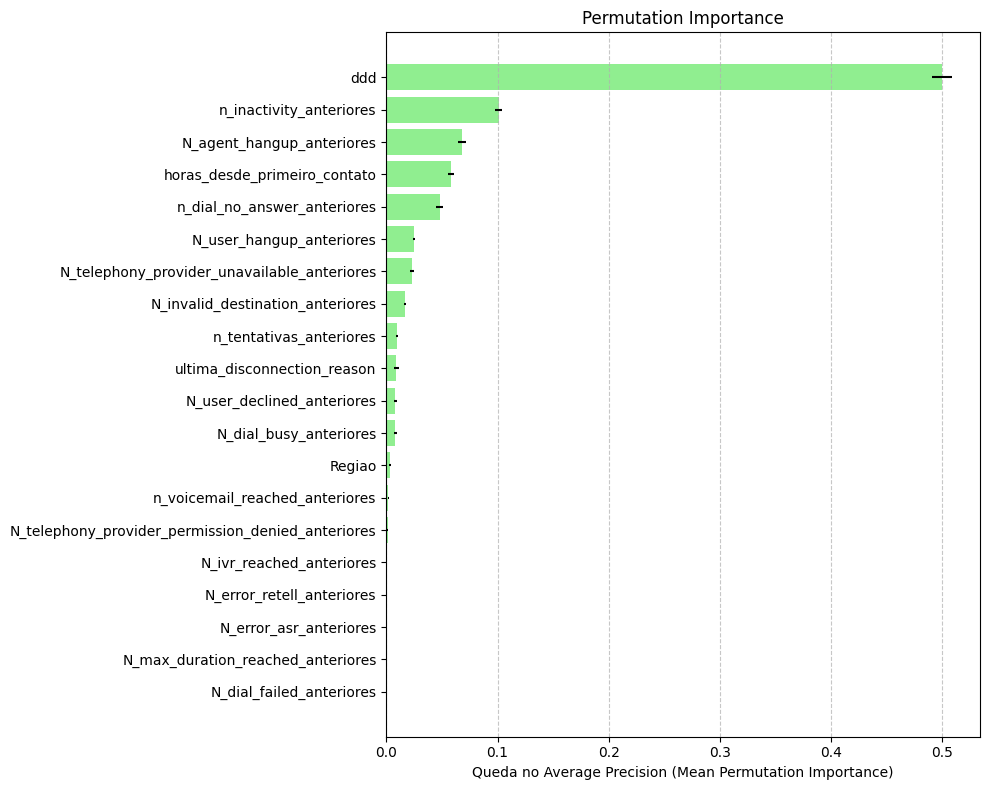

Ranking de Permutation Importance (Top 20):
                                          feature  importance_mean  importance_std
                                              ddd         0.499313        0.009067
                          n_inactivity_anteriores         0.100888        0.003022
                        N_agent_hangup_anteriores         0.067681        0.003572
                     horas_desde_primeiro_contato         0.058293        0.002867
                      n_dial_no_answer_anteriores         0.047954        0.003355
                         N_user_hangup_anteriores         0.024710        0.001011
      N_telephony_provider_unavailable_anteriores         0.023070        0.001741
                 N_invalid_destination_anteriores         0.016754        0.001252
                          n_tentativas_anteriores         0.009695        0.000799
                      ultima_disconnection_reason         0.009077        0.001869
                       N_user_declined_ante

In [7]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Corrigido: Usando as variáveis X e y que estão definidas no notebook
# Se você quiser usar um conjunto de teste, precisará fazer o train_test_split antes

print("Calculando Permutation Importance...")
r = permutation_importance(model, X, y,
                           n_repeats=10,
                           random_state=42,
                           n_jobs=-1,
                           scoring='average_precision')

# Organizando os resultados em um DataFrame
feature_names = X.columns
perm_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values(by='importance_mean', ascending=False)

# Plotando os resultados
plt.figure(figsize=(10, 8))
plt.barh(perm_imp_df['feature'], perm_imp_df['importance_mean'], xerr=perm_imp_df['importance_std'], color='lightgreen')
plt.xlabel('Queda no Average Precision (Mean Permutation Importance)')
plt.title('Permutation Importance')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Ranking de Permutation Importance (Top 20):")
print(perm_imp_df.head(20).to_string(index=False))